In [2]:
import sys
from pathlib import Path
project_root = Path.cwd().parent  # 假设 Notebook 在项目根目录的 notebooks 子目录中
sys.path.append(str(project_root))
import numpy as np
import pickle
from joblib import Parallel, delayed
from src.get_emis_abso import get_emis_abso
from src.models import rsm_wsgg as rsm
from pyDOE3 import lhs

# 设置总压
pressure = 1.0  # 压力，单位为 bar

# 设置参与性气体的摩尔分数和
X = 0.2
###############################################################################################################响应面方法，拉丁超立方采样begin
# 定义因素的取值范围
T_min, T_max = 300.0, 2400.0  # 温度范围 (K)
Mr_min, Mr_max = 0.1, 4.0  # 摩尔分数比范围
pL_min, pL_max = 0.01, 60.0  # 压力路径范围

# 生成一个3因素的拉丁超立方设计，每个因素的采样点数为30
design = lhs(3, samples=40, criterion='center')

# 应用幂变换，使样本在靠近0的位置更密集
transformed_design = design ** 2

# 转换采样点到指定范围
# temperatures = T_min + (T_max - T_min) * design[:, 0]  # 温度线性采样
# temperatures = T_min + (T_max - T_min) * transformed_design[:, 0]  # 温度非线性采样
# mole_fraction_ratios = Mr_min + (Mr_max - Mr_min) * transformed_design[:, 1]  # 摩尔分数比
# path_lengths = pL_min + (pL_max - pL_min) * transformed_design[:, 2]  # 压力路径

###############################################################################################################响应面方法，拉丁超立方采样end
# 定义温度的范围
temperatures = np.arange(300.0, 2401.0, 100.0)
# temperatures = [300.0, 350.0, 400.0, 450.0, 500.0, 550.0, 600.0, 650.0, 700.0, 750.0, 800.0, 850.0, 900.0, 1000.0, 1100.0, 1200.0, 1300.0, 
#                1400.0, 1500.0, 1600.0, 1700.0, 1800.0, 1900.0, 2000.0, 2100.0, 2200.0, 2300.0, 2400.0]
# 定义摩尔分数比范围
mole_fraction_ratios = [0.1, 0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
# temperatures = [700.0, 1100.0, 1500.0, 1600.0, 1700.0, 1800.0, 1900.0, 2000.0, 2100.0, 2200.0, 2300.0, 2400.0]
_, _, path_lengths, _ = rsm.load_and_process_emissivity_data('../input/MixEmiss_p1.0_X0.2_Mr0.1-4.0_40_T40_path40.npy')

# 定义路径长度范围，单位为米（m）
# path_lengths = np.array([0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0, 10.0, 15.0, 20.0, 30.0, 40.0, 50.0, 60.0])

# 打印结果
print("Temperature (T):", temperatures)
print("Mole Fraction Ratio (Mr):", mole_fraction_ratios)
print("Pressure Path (pL):", path_lengths)

# 创建文件名，包含物质种类、压力、摩尔分数个数、温度个数和路径长度个数信息
filename_mix = f'../input/MixEmiss_p{pressure}_X{X}_Mr{Mr_min}-{Mr_max}_{len(mole_fraction_ratios)}_T{len(temperatures)}_path{len(path_lengths)}.npy'

def process_mole_fraction_temperature(mole_fraction_ratio, Tgas, path_lengths, pressure):
    mole_fraction_nh3 = X / (1 + mole_fraction_ratio)
    mole_fraction_h2o = mole_fraction_ratio * X / (1 + mole_fraction_ratio)
    results = []
    # 计算混合物吸收系数
    # 壁面温度在 WSGG 模型中没有用到，为了兼容get_emis_abso接口，这里给定 Ts 为 300K
    Ts = 300.0
    for path_length in path_lengths:
        # 把压力路径的单位转换为bar*cm
        pLenth = pressure * path_length * 100
        # 在本 WSGG 模型中只用到了H2O和NH3两种气体，为了兼容get_emis_abso接口，这里给定第三种气体的摩尔分数为 0
        x3 = 0.0
        emis, abso = get_emis_abso(pressure, Tgas, Ts, pLenth, mole_fraction_h2o, mole_fraction_nh3, x3)
        results.append((path_length, emis))
    
    return results

# 初始化 all_data 字典
all_data = {mole_fraction_ratio: {} for mole_fraction_ratio in mole_fraction_ratios}

# 使用 Parallel 并行化处理
results = Parallel(n_jobs=-1)(
    delayed(process_mole_fraction_temperature)(mole_fraction_ratio, Tgas, path_lengths, pressure)
    for mole_fraction_ratio in mole_fraction_ratios for Tgas in temperatures)

# 合并结果到 all_data
for (mole_fraction_ratio, Tgas), result in zip([(mfr, T) for mfr in mole_fraction_ratios for T in temperatures], results):
    all_data[mole_fraction_ratio][Tgas] = result

# 保存所有数据到文件
with open(filename_mix, 'wb') as f:
    pickle.dump(all_data, f)

print(f"计算完成，Mix的结果已保存到 {filename_mix}")

Temperature (T): [ 300.  400.  500.  600.  700.  800.  900. 1000. 1100. 1200. 1300. 1400.
 1500. 1600. 1700. 1800. 1900. 2000. 2100. 2200. 2300. 2400.]
Mole Fraction Ratio (Mr): [0.1, 0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
Pressure Path (pL): [1.93734375e-02 9.43609375e-02 2.44335938e-01 4.69298438e-01
 7.69248438e-01 1.14418594e+00 1.59411094e+00 2.11902344e+00
 2.71892344e+00 3.39381094e+00 4.14368594e+00 4.96854844e+00
 5.86839844e+00 6.84323594e+00 7.89306094e+00 9.01787344e+00
 1.02176734e+01 1.14924609e+01 1.28422359e+01 1.42669984e+01
 1.57667484e+01 1.73414859e+01 1.89912109e+01 2.07159234e+01
 2.25156234e+01 2.43903109e+01 2.63399859e+01 2.83646484e+01
 3.04642984e+01 3.26389359e+01 3.48885609e+01 3.72131734e+01
 3.96127734e+01 4.20873609e+01 4.46369359e+01 4.72614984e+01
 4.99610484e+01 5.27355859e+01 5.55851109e+01 5.85096234e+01]
计算完成，Mix的结果已保存到 ../input/MixEmiss_p1.0_X0.2_Mr0.1-4.0_15_T22_path40.npy


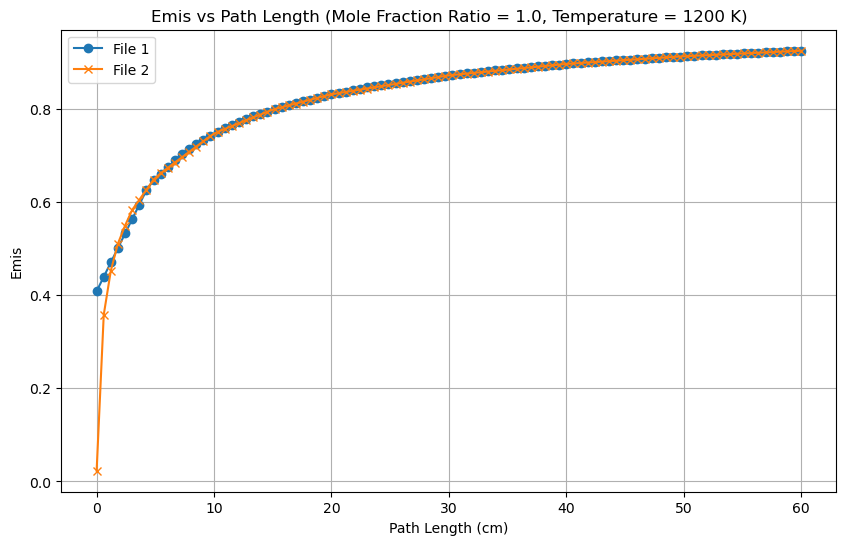

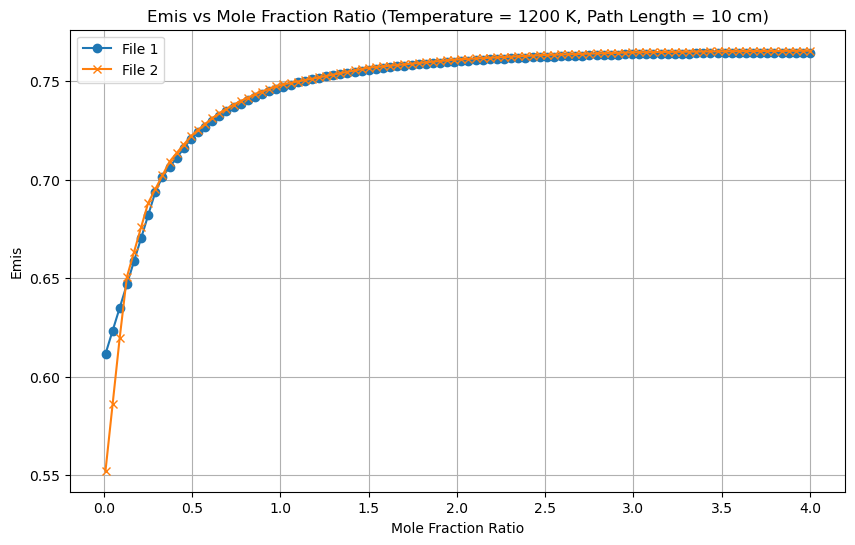

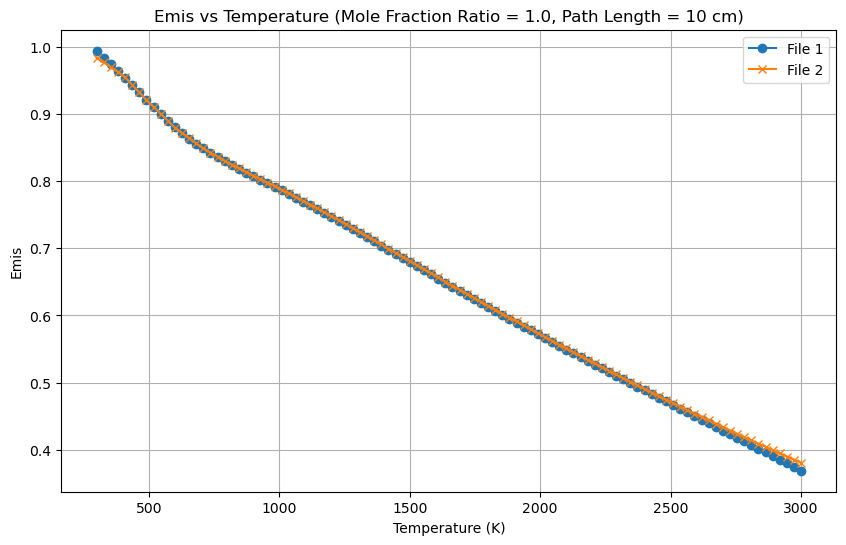

In [13]:
import matplotlib.pyplot as plt
import pickle
import numpy as np
from scipy.interpolate import interp1d

def load_and_process_emissivity_data(filename):
    """
    从文件中读取发射率数据库，并装配出mole_fraction_ratios、temperatures、path_lengths三个一维数组
    和一个三维的epsilon_3d数组。

    参数:
    filename (str): 发射率数据库文件的名称。

    返回:
    mole_fraction_ratios (np.array): 摩尔分数比数组。
    temperatures (np.array): 温度数组。
    path_lengths (np.array): 路径长度数组。
    epsilon_3d (np.array): 三维的发射率epsilon数组。
    """
    with open(filename, 'rb') as f:
        all_data = pickle.load(f)

    # 提取唯一的 mole_fraction_ratio、Tgas 和 path_length_value
    unique_mole_fraction_ratios = list(all_data.keys())
    unique_temperatures = list(next(iter(all_data.values())).keys())
    unique_path_lengths = sorted(set([item[0] for item in next(iter(next(iter(all_data.values())).values()))]))
    
    # 保存一维数组
    mole_fraction_ratios = np.array(unique_mole_fraction_ratios)
    temperatures = np.array(unique_temperatures)
    path_lengths = np.array(unique_path_lengths)

    # 初始化 epsilon 的三维数组
    epsilon_3d = np.zeros((len(unique_mole_fraction_ratios), len(unique_temperatures), len(unique_path_lengths)))

    # 填充 epsilon_3d 数组
    for idx_mfr, mole_fraction_ratio in enumerate(unique_mole_fraction_ratios):
        for idx_T, Tgas in enumerate(unique_temperatures):
            for idx_pl, path_length_value in enumerate(unique_path_lengths):
                # 查找对应的 epsilon 值
                epsilon_values = all_data[mole_fraction_ratio][Tgas]
                for pl_value, epsilon in epsilon_values:
                    if pl_value == path_length_value:
                        epsilon_3d[idx_mfr, idx_T, idx_pl] = epsilon
                        break
    # 打印结果以验证
    # print("摩尔分数比数组:", mole_fraction_ratios_array)
    # print("温度数组:", temperatures_array)
    # print("路径长度数组:", path_lengths_array)
    # print("发射率数组:", epsilon_3d)
    return mole_fraction_ratios, temperatures, path_lengths, epsilon_3d

# 加载两个文件的数据
filename1 = 'MixEmiss_p1.0_mf20_T20_path20.npy'
filename2 = 'MixEmiss_p1.0_mf15_T28_path20.npy'

mole_fraction_ratios1, temperatures1, path_lengths1, epsilon_3d1 = load_and_process_emissivity_data(filename1)
mole_fraction_ratios2, temperatures2, path_lengths2, epsilon_3d2 = load_and_process_emissivity_data(filename2)


def interpolate_emissivity(mole_fraction_ratios, temperatures, path_lengths, epsilon_3d, target_mfr, target_T, target_pl):
    """
    通过插值计算给定温度、摩尔分数和路径长度下的发射率。

    参数:
    mole_fraction_ratios (np.array): 摩尔分数比数组。
    temperatures (np.array): 温度数组。
    path_lengths (np.array): 路径长度数组。
    epsilon_3d (np.array): 三维的发射率epsilon数组。
    target_mfr (float): 目标摩尔分数比。
    target_T (float): 目标温度。
    target_pl (float): 目标路径长度。

    返回:
    interpolated_emis (float): 插值后的发射率。
    """
    # 创建插值函数
    f = interp1d(mole_fraction_ratios, epsilon_3d, kind='linear', axis=0, fill_value="extrapolate")
    interpolated_emis_mfr = f(target_mfr)

    f = interp1d(temperatures, interpolated_emis_mfr, kind='linear', axis=0, fill_value="extrapolate")
    interpolated_emis_T = f(target_T)

    f = interp1d(path_lengths, interpolated_emis_T, kind='linear', fill_value="extrapolate")
    interpolated_emis = f(target_pl)

    return interpolated_emis


# 选择特定的温度、摩尔分数和路径长度
target_mfr = 1.0  # 选择特定的摩尔分数比
target_T = 1200  # 选择特定的温度
target_pl = 10  # 选择特定的路径长度

# 计算插值后的发射率
interpolated_emis1 = interpolate_emissivity(mole_fraction_ratios1, temperatures1, path_lengths1, epsilon_3d1, target_mfr, target_T, target_pl)
interpolated_emis2 = interpolate_emissivity(mole_fraction_ratios2, temperatures2, path_lengths2, epsilon_3d2, target_mfr, target_T, target_pl)

# 第一张图：emis 随路径长度的变化
path_lengths_to_plot = np.linspace(min(path_lengths1.min(), path_lengths2.min()), max(path_lengths1.max(), path_lengths2.max()), 100)
emis_vs_path_length1 = [interpolate_emissivity(mole_fraction_ratios1, temperatures1, path_lengths1, epsilon_3d1, target_mfr, target_T, pl) for pl in path_lengths_to_plot]
emis_vs_path_length2 = [interpolate_emissivity(mole_fraction_ratios2, temperatures2, path_lengths2, epsilon_3d2, target_mfr, target_T, pl) for pl in path_lengths_to_plot]

plt.figure(figsize=(10, 6))
plt.plot(path_lengths_to_plot, emis_vs_path_length1, marker='o', label='File 1')
plt.plot(path_lengths_to_plot, emis_vs_path_length2, marker='x', label='File 2')
plt.title(f'Emis vs Path Length (Mole Fraction Ratio = {target_mfr}, Temperature = {target_T} K)')
plt.xlabel('Path Length (cm)')
plt.ylabel('Emis')
plt.legend()
plt.grid(True)
plt.show()

# 第二张图：emis 随摩尔分数的变化
mole_fraction_ratios_to_plot = np.linspace(min(mole_fraction_ratios1.min(), mole_fraction_ratios2.min()), max(mole_fraction_ratios1.max(), mole_fraction_ratios2.max()), 100)
emis_vs_mole_fraction1 = [interpolate_emissivity(mole_fraction_ratios1, temperatures1, path_lengths1, epsilon_3d1, mfr, target_T, target_pl) for mfr in mole_fraction_ratios_to_plot]
emis_vs_mole_fraction2 = [interpolate_emissivity(mole_fraction_ratios2, temperatures2, path_lengths2, epsilon_3d2, mfr, target_T, target_pl) for mfr in mole_fraction_ratios_to_plot]

plt.figure(figsize=(10, 6))
plt.plot(mole_fraction_ratios_to_plot, emis_vs_mole_fraction1, marker='o', label='File 1')
plt.plot(mole_fraction_ratios_to_plot, emis_vs_mole_fraction2, marker='x', label='File 2')
plt.title(f'Emis vs Mole Fraction Ratio (Temperature = {target_T} K, Path Length = {target_pl} cm)')
plt.xlabel('Mole Fraction Ratio')
plt.ylabel('Emis')
plt.legend()
plt.grid(True)
plt.show()

# 第三张图：emis 随温度的变化
temperatures_to_plot = np.linspace(min(temperatures1.min(), temperatures2.min()), max(temperatures1.max(), temperatures2.max()), 100)
emis_vs_temperature1 = [interpolate_emissivity(mole_fraction_ratios1, temperatures1, path_lengths1, epsilon_3d1, target_mfr, T, target_pl) for T in temperatures_to_plot]
emis_vs_temperature2 = [interpolate_emissivity(mole_fraction_ratios2, temperatures2, path_lengths2, epsilon_3d2, target_mfr, T, target_pl) for T in temperatures_to_plot]

plt.figure(figsize=(10, 6))
plt.plot(temperatures_to_plot, emis_vs_temperature1, marker='o', label='File 1')
plt.plot(temperatures_to_plot, emis_vs_temperature2, marker='x', label='File 2')
plt.title(f'Emis vs Temperature (Mole Fraction Ratio = {target_mfr}, Path Length = {target_pl} cm)')
plt.xlabel('Temperature (K)')
plt.ylabel('Emis')
plt.legend()
plt.grid(True)
plt.show()